In [2]:
import os
import pandas as pd
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
import glob
import re
from pathlib import Path
import ast
import matplotlib.ticker as ticker
from statsmodels.stats.proportion import proportion_confint

In [2]:
def tflog2pandas(path, filter_tags=None):
    runlog_data = pd.DataFrame()
    ea = event_accumulator.EventAccumulator(path, size_guidance={"scalars": 0})
    ea.Reload()

    tags = ea.Tags()["scalars"]

    for tag in tags:
        if filter_tags is not None and tag not in filter_tags:
            continue
        event_list = ea.Scalars(tag)
        values = [e.value for e in event_list]
        steps = [e.step for e in event_list]
        tag_df = pd.DataFrame({tag: values, "step": steps})
        
        if runlog_data.empty:
            runlog_data = tag_df
        else:
            runlog_data = pd.merge(runlog_data, tag_df, on="step", how="outer")

    return runlog_data


In [60]:
dftrain = tflog2pandas("./runs/supervised/final_model/train", ["Loss"])
dfvalidation = tflog2pandas("./runs/supervised/final_model/validation", ["Loss"])

In [29]:
plt.style.use("science")

In [80]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

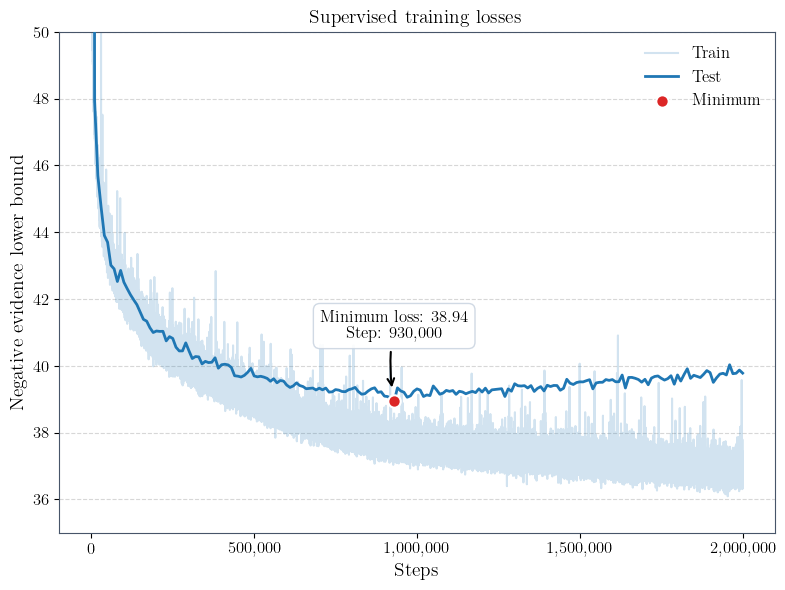

In [85]:
min_loss_idx = dfvalidation["Loss"].idxmin()
min_step = dfvalidation.loc[min_loss_idx, "step"]
min_loss = dfvalidation.loc[min_loss_idx, "Loss"]

plt.figure(figsize=(8, 6))

# 1. Mute the Training Line 
plt.plot(dftrain["step"], dftrain["Loss"], 
         label="Train", 
         color="tab:blue",
         alpha=0.2,
         linewidth=1.5, 
        )

# 2. Emphasize the Validation/Test Line 
plt.plot(dfvalidation["step"], dfvalidation["Loss"], 
         label="Test", 
         color="tab:blue", 
        #  linewidth=2.5,
         linewidth=2,
         zorder=4)

# 3. Style the Minimum Point 
plt.scatter(min_step, min_loss, 
            color="#DC2626", 
            s=80, 
            edgecolors="white", 
            linewidths=1.5, 
            zorder=5, 
            label="Minimum")

# 4. Clean up the Annotation 
plt.annotate(
    f"Minimum loss: {min_loss:.2f}\nStep: {min_step:,.0f}", 
    xy=(min_step, min_loss), 
    xytext=(0, 45), 
    textcoords="offset points",
    arrowprops=dict(
        arrowstyle="->", 
        color="black", 
        lw=1.5,
        connectionstyle="arc3,rad=0.1",
        shrinkB=10  # <--- THIS IS THE FIX: pulls the arrow tip away from the dot
    ),
    fontsize=12,
    ha="center",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#CBD5E1", alpha=0.9)
)

# --- Formatting ---
plt.ylim((35, 50))
plt.xlabel("Steps", fontsize=14)
plt.ylabel("Negative evidence lower bound", fontsize=14)
plt.title("Supervised training losses", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Legend adjustments
plt.legend(fontsize=12, frameon=False)

# Grid and Spines
ax = plt.gca()
ax.spines["top"].set_color("#475569")
ax.spines["right"].set_color("#475569")
ax.spines["left"].set_color("#475569")
ax.spines["bottom"].set_color("#475569")

# X-axis ticker formatting
ax.xaxis.set_major_locator(ticker.MultipleLocator(500_000))
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Grid
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(f"../Thesis/sections/figures/supervised_training_progress/Training_loss.pdf")
plt.show()


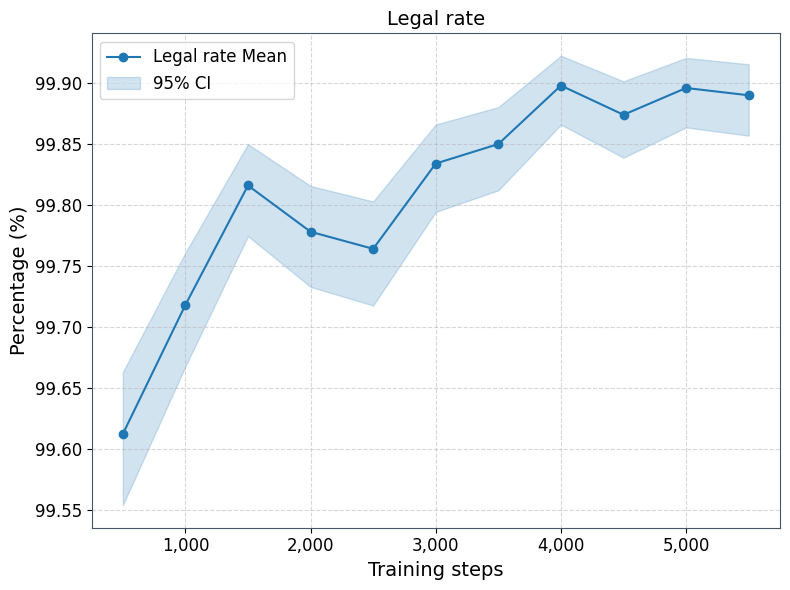

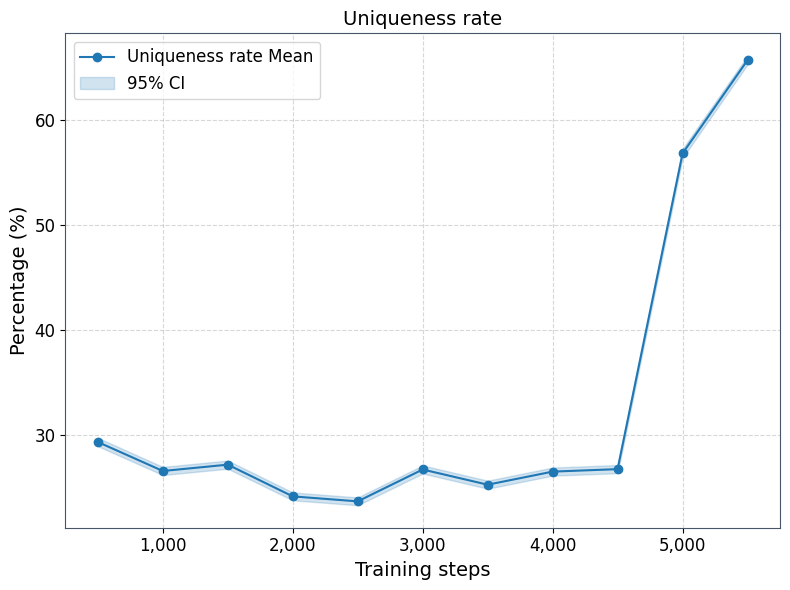

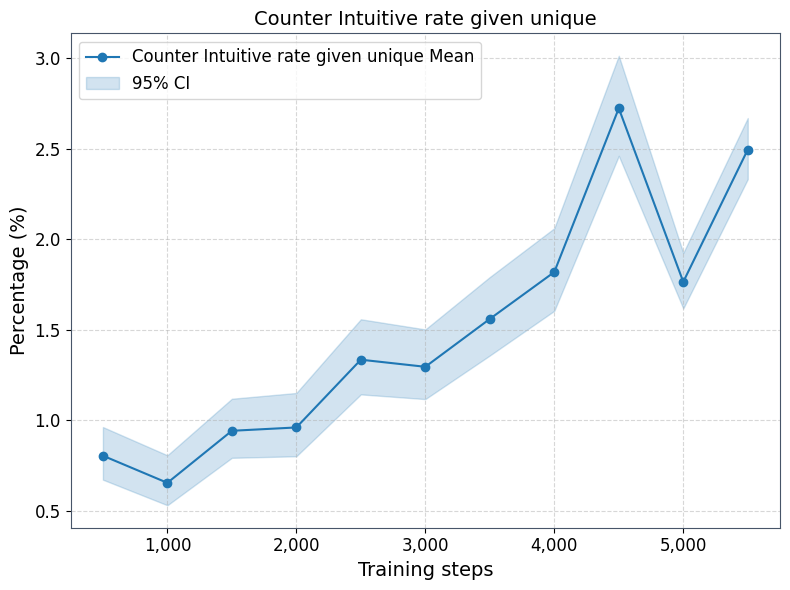

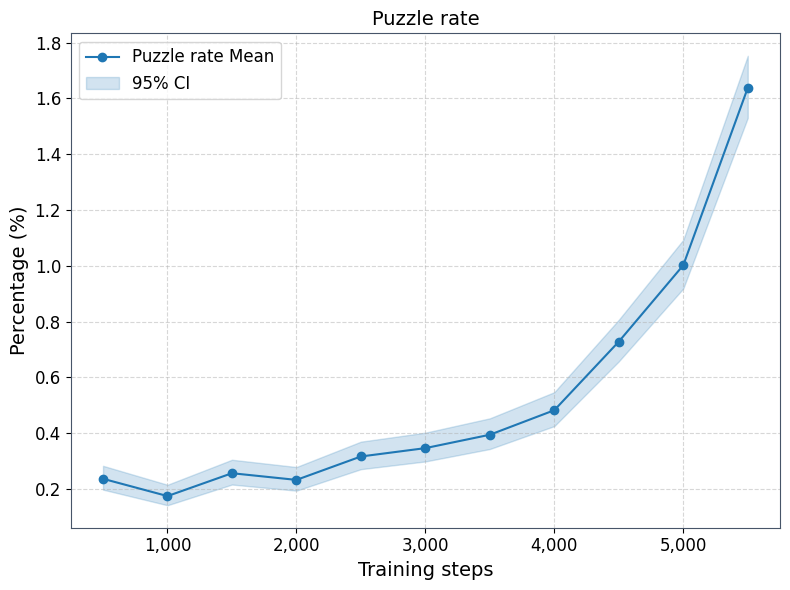

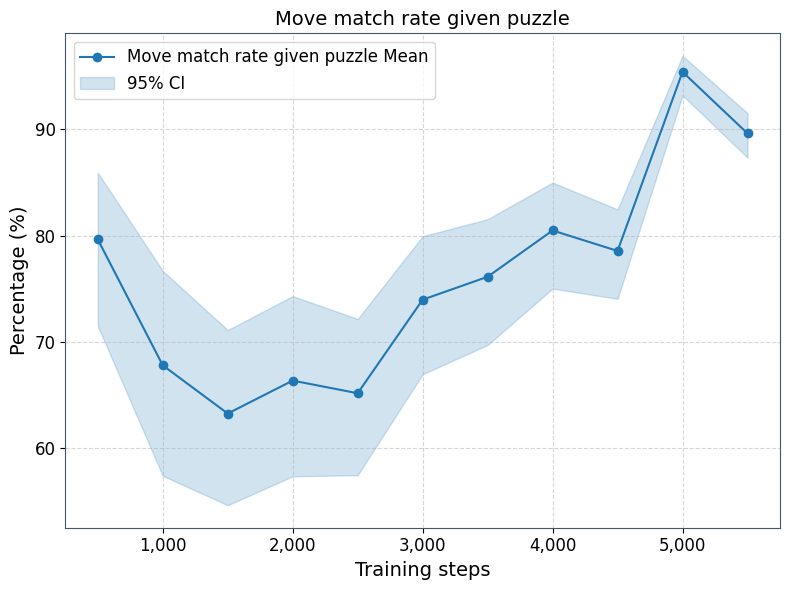

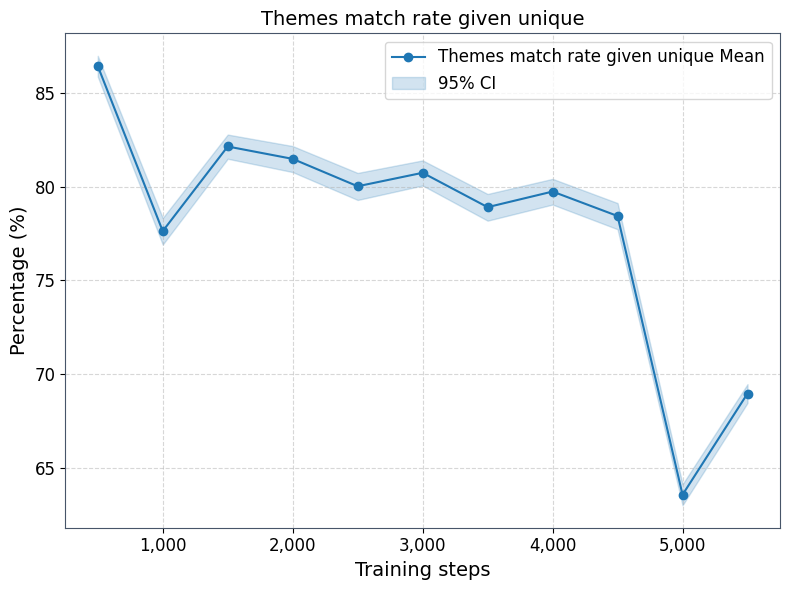

In [47]:
# folder_path = "Generate_positions/final_model/supervised/training_progress/train_no_move_last"
# folder_path = "Generate_positions/final_model/supervised/training_progress/test_no_move_last"
folder_path = "Generate_positions/final_model/rl/training_progress/test_no_move_last"
needed_columns = ["is_legal", "is_puzzle", "counter_intuitive", "themes_match", "best_move", "main_line"]
file_pattern = os.path.join(folder_path, 'model_*.csv')
file_paths = sorted(glob.glob(file_pattern), key=lambda f: int(re.search(r'model_(\d+)\.csv', f).group(1)))

data_points = []
for file in file_paths:
    model_number = int(re.search(r'model_(\d+)\.csv', os.path.basename(file)).group(1))
    df = pd.read_csv(file, usecols=needed_columns)
    
    # Define dataset subsets
    n_total = len(df)
    unique_positions = df[df["is_puzzle"]]
    unique_and_counter_intuitive = df[df["is_puzzle"] & df["counter_intuitive"]]
    
    # Store both count and the specific 'n' for each metric
    row = {
        "model_number": model_number,
        "Legal rate": {
            "count": df["is_legal"].sum(), 
            "n": n_total
        },
        "Uniqueness rate": {
            "count": df["is_puzzle"].sum(), 
            "n": n_total
        },
        "Counter Intuitive rate given unique": {
            "count": unique_positions["counter_intuitive"].sum(), 
            "n": len(unique_positions)
        },
        "Puzzle rate": {
            "count": (df["is_puzzle"] & df["counter_intuitive"]).sum(), 
            "n": n_total
        },
        "Move match rate given puzzle": {
            "count": (unique_and_counter_intuitive["main_line"].str.split(" ").str[0] == unique_and_counter_intuitive["best_move"]).sum(), 
            "n": len(unique_and_counter_intuitive)
        },
        "Themes match rate given unique": {
            "count": unique_positions["themes_match"].sum(),
            "n": len(unique_positions)
        }
    }
    data_points.append(row)

# Convert to DataFrame
df_results = pd.DataFrame(data_points)

# 2. Plotting with Uncertainty
metrics = [
    "Legal rate", 
    "Uniqueness rate", 
    "Counter Intuitive rate given unique", 
    "Puzzle rate", 
    "Move match rate given puzzle",
    "Themes match rate given unique"
]

for metric in metrics:
    plt.figure(figsize=(8, 6))
    
    x = df_results["model_number"]
    counts = np.array([d["count"] for d in df_results[metric]])
    n_vals = np.array([d["n"] for d in df_results[metric]])    
    means = 100 * counts / n_vals
    
    low = np.zeros_like(means)
    high = np.zeros_like(means)
    
    low, high = proportion_confint(counts, n_vals, alpha=0.05, method="wilson")
    
    # Plotting
    plt.plot(x, means, marker="o", linestyle="-", label=f"{metric} Mean", c="tab:blue")
    plt.fill_between(x, low * 100, high * 100, color="tab:blue", alpha=0.2, label="95% CI")
    
    plt.xlabel("Training steps", fontsize=14)
    plt.ylabel("Percentage (%)", fontsize=14)
    plt.title(metric, fontsize=14)

    ax = plt.gca()
    ax.spines["top"].set_color("#475569")
    ax.spines["right"].set_color("#475569")
    ax.spines["left"].set_color("#475569")
    ax.spines["bottom"].set_color("#475569")
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1_000))
    # ax.ticklabel_format(style="plain", axis="x")
    ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.legend(fontsize=12)
    plt.grid(which="both", linestyle='--', alpha=0.5)
    plt.tight_layout()
    # plt.savefig(f"../Thesis/sections/figures/supervised_training_progress/train/{metric.replace(' ', '_')}.pdf")
    # plt.savefig(f"../Thesis/sections/figures/supervised_training_progress/test/{metric.replace(' ', '_')}.pdf")
    # plt.savefig(f"../Thesis/sections/figures/rl_training_progress/good_run/{metric.replace(' ', '_')}.pdf")
    plt.show()

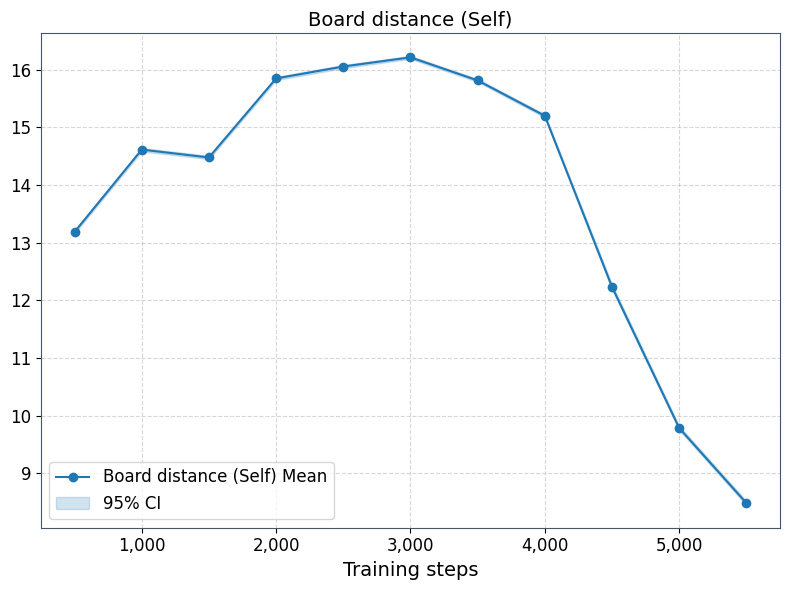

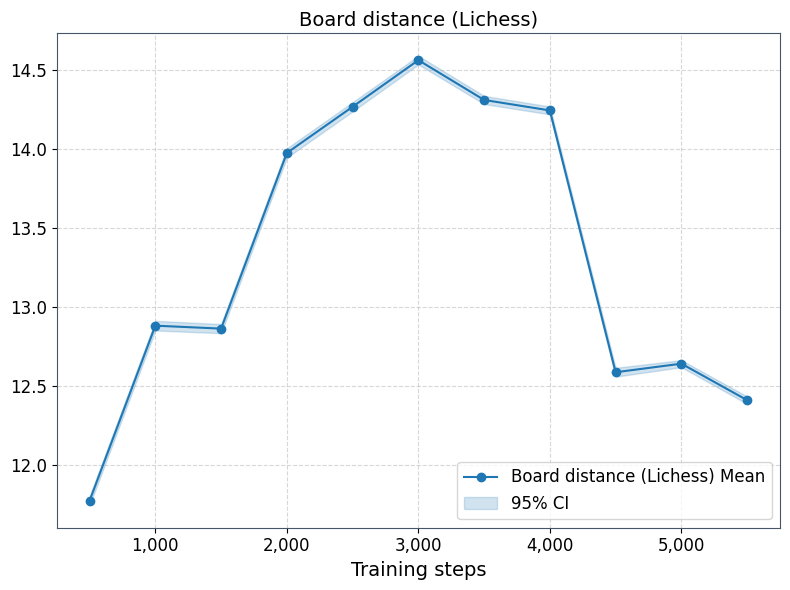

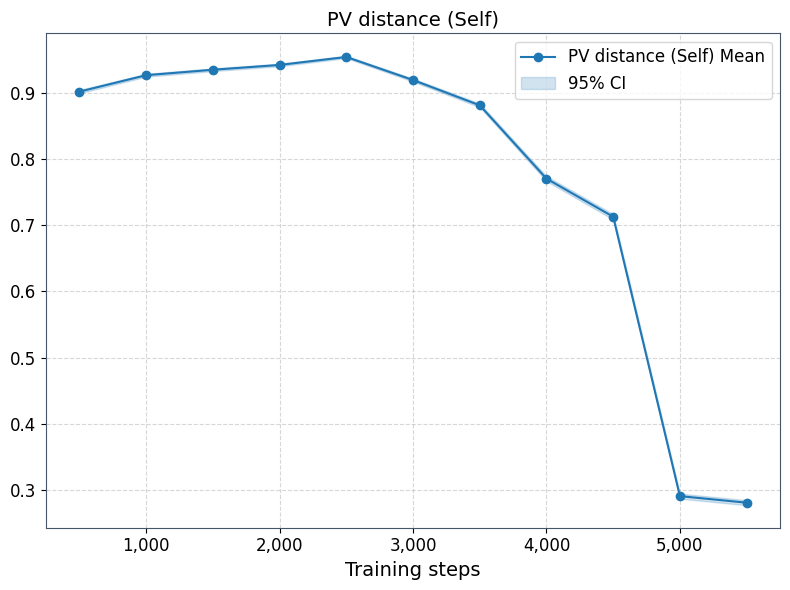

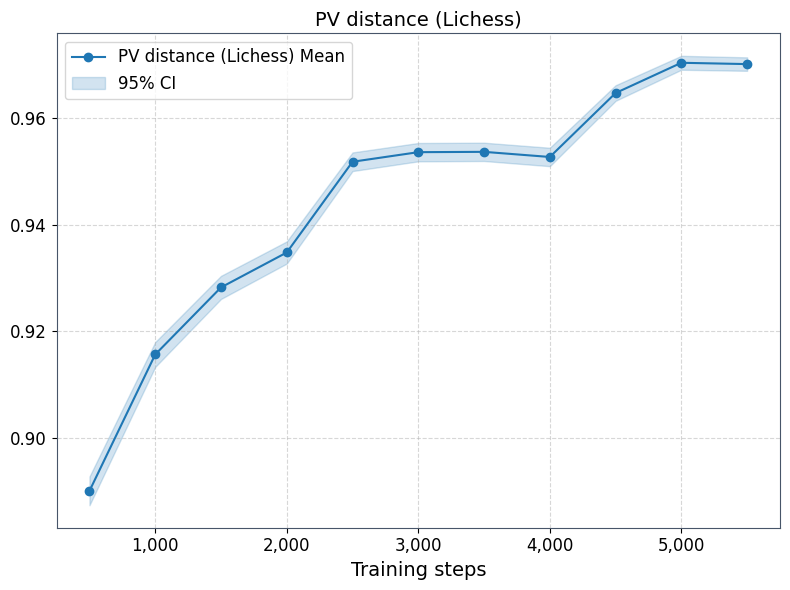

In [ ]:
path = "Generate_positions/final_model/rl/training_progress/test_no_move_last/distances.csv"
df = pd.read_csv(path)

metrics = {"Board distance (Self)": "self_distance_board", "Board distance (Lichess)": "lichess_distance_board", "PV distance (Self)": "self_distance_pv", "PV distance (Lichess)": "lichess_distance_pv"}
for name, metric in metrics.items():
    plt.figure(figsize=(8, 6))

    # Plotting
    plt.plot(df["checkpoint"], df[metric], marker="o", linestyle="-", c="tab:blue", label=f"{name} Mean")
    plt.fill_between(df["checkpoint"], df[metric] - df[metric + "_standard_error"], df[metric] + df[metric + "_standard_error"], alpha=0.2, color="tab:blue", label="95% CI")

    plt.xlabel("Training steps", fontsize=14)
    plt.title(name, fontsize=14)

    ax = plt.gca()
    ax.spines["top"].set_color("#475569")
    ax.spines["right"].set_color("#475569")
    ax.spines["left"].set_color("#475569")
    ax.spines["bottom"].set_color("#475569")
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1_000))
    # ax.ticklabel_format(style="plain", axis="x")
    ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # plt.legend(fontsize=12)
    plt.grid(which="both", linestyle='--', alpha=0.5)
    plt.legend(fontsize=12)
    plt.tight_layout()
    # plt.savefig(f"../Thesis/sections/figures/rl_training_progress/good_run/{metric.replace(' ', '_')}.pdf")
    plt.show()

In [10]:
log_path = "../src/runs/rl/final_large_runs/final_thesis_experiments/full_diversity11"
df = tflog2pandas(log_path)
df.index = range(len(df))

In [11]:
df

,Components/legal_rate,step,Components/uniqueness_rate,Components/counter_intuitive_rate,Components/counter_intuitive_values,Components/counter_intuitive_values_given_unique,Components/counter_intuitive_rate_given_unique,Components/unique_and_counter_intuitive,Components/piece_counts,Components/themes_match_rate,...,Components/pass_diversity_filtering,Components/move_match_rate,Components/cp_loss,Loss/Total Loss,Loss/RL Grad Norm,Loss/KL divergence,Loss/Clips,Loss/learning_rate,Reward,Loss/Entropy
0,0.989583,0,0.312500,0.093750,0.017213,-0.008444,0.000000,0.000000,0.968421,0.833333,...,0.431579,0.705263,0.000000,-0.008433,0.167187,2.494292e-08,0.0,0.00001,-0.015833,5.370569
1,0.979167,1,0.270833,0.114583,0.025759,-0.000479,0.000000,0.000000,0.978723,0.884615,...,0.319149,0.489362,71.227272,-0.008263,0.236529,1.782079e-07,0.0,0.00002,-0.041667,5.281883
2,0.989583,2,0.260417,0.083333,0.006347,-0.013387,0.000000,0.000000,0.978947,0.680000,...,0.389474,0.578947,35.040001,-0.008303,0.173803,1.138926e-04,0.0,0.00003,-0.020833,5.314178
3,0.968750,3,0.416667,0.083333,0.011588,-0.007933,0.000000,0.000000,1.000000,1.000000,...,0.365591,0.645161,0.000000,-0.008258,0.223677,6.824259e-04,0.0,0.00003,-0.061991,5.329084
4,0.979167,4,0.479167,0.031250,-0.003384,-0.004106,0.000000,0.000000,0.968085,0.978261,...,0.287234,0.723404,0.000000,-0.008022,0.238853,2.566474e-03,0.0,0.00003,-0.041667,5.185784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5709,0.989583,5709,0.593750,0.125000,0.032750,0.041263,0.140351,0.083333,0.968421,0.771930,...,0.210526,0.736842,0.000000,-0.007901,0.290667,3.131344e+01,0.0,0.00003,0.027500,5.232040
5710,1.000000,5710,0.531250,0.114583,0.037468,0.024157,0.019608,0.010417,0.937500,0.686275,...,0.354167,0.697917,4.187500,-0.007969,0.424004,3.319732e+01,0.0,0.00003,0.013333,5.301008
5711,1.000000,5711,0.635417,0.125000,0.034741,0.020095,0.032787,0.020833,0.979167,0.901639,...,0.260417,0.864583,0.000000,-0.007829,0.233139,3.679799e+01,0.0,0.00003,0.013333,5.273230
5712,1.000000,5712,0.333333,0.083333,0.023241,0.018500,0.000000,0.000000,0.947917,0.812500,...,0.333333,0.583333,0.000000,-0.008223,0.188401,2.348984e+01,0.0,0.00003,0.005000,5.393070


In [25]:
def plotv1(col: pd.DataFrame, alpha=0.001, start=0, label=("", "95% CI")):
    ewm_mean = col.ewm(alpha=alpha).mean()
    ewm_std = col.ewm(alpha=alpha).std()
    
    ci_lower = ewm_mean - 1.96 * ewm_std
    ci_upper = ewm_mean + 1.96 * ewm_std
    
    plt.plot(col.index[start:], ewm_mean.iloc[start:], color="tab:blue", label=label[0])
    
    plt.fill_between(
        col.index[start:], 
        ci_lower.iloc[start:], 
        ci_upper.iloc[start:], 
        color="tab:blue", 
        alpha=0.2,
        label=label[1]
    )

def plotv2(col: pd.Series, alpha=0.001, start=0, label=("", "95% CI")):
    ewm_mean = col.ewm(alpha=alpha).mean()
    ewm_std = col.ewm(alpha=alpha).std()
    
    n_eff = (2 - alpha) / alpha    
    sem = ewm_std / np.sqrt(n_eff)
    ci_lower = ewm_mean - (1.96 * sem)
    ci_upper = ewm_mean + (1.96 * sem)
    
    plt.plot(col.index[start:], ewm_mean.iloc[start:], color="tab:blue", label=label[0])
    plt.fill_between(
        col.index[start:], 
        ci_lower.iloc[start:], 
        ci_upper.iloc[start:], 
        color="tab:blue", 
        alpha=0.2,
        label=label[1]
    )


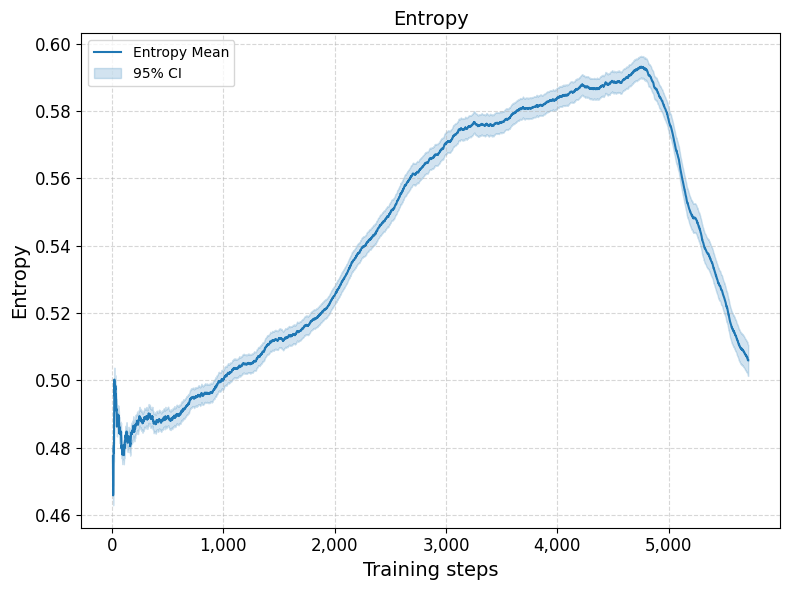

In [ ]:
plt.figure(figsize=(8, 6))
plt.title("Entropy", fontsize=14)
plotv2(df["Loss/Entropy"] - np.log(128), start=10, label=("Entropy Mean", "95% CI"))

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(1000))
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(which="both", linestyle='--', alpha=0.5)
plt.xlabel("Training steps", fontsize=14)
plt.ylabel("Entropy", fontsize=14)
plt.legend()
plt.tight_layout()
# plt.savefig(f"../Thesis/sections/figures/rl_training_progress/good_run/Entropy.pdf")
plt.show()

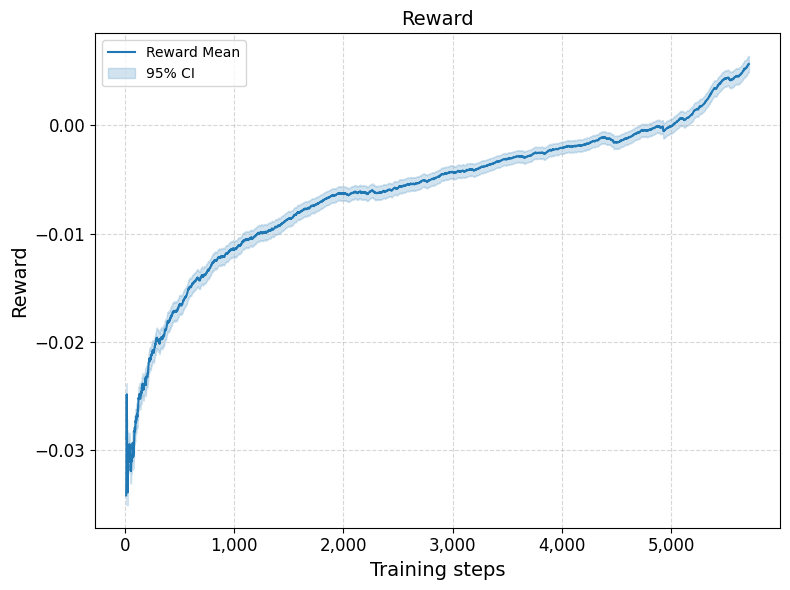

In [ ]:
plt.figure(figsize=(8, 6))
plt.title("Reward", fontsize=14)
plotv2(df["Reward"], start=10, label=("Reward Mean", "95% CI"))

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(1000))
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(which="both", linestyle='--', alpha=0.5)
plt.xlabel("Training steps", fontsize=14)
plt.ylabel("Reward", fontsize=14)
plt.legend()
plt.tight_layout()
# plt.savefig(f"../Thesis/sections/figures/rl_training_progress/good_run/Reward.pdf")
plt.show()

In [62]:
df.columns

Index(['Components/legal_rate', 'step', 'Components/uniqueness_rate',
       'Components/counter_intuitive_rate',
       'Components/counter_intuitive_values',
       'Components/counter_intuitive_values_given_unique',
       'Components/counter_intuitive_rate_given_unique',
       'Components/unique_and_counter_intuitive', 'Components/piece_counts',
       'Components/themes_match_rate', 'Components/dist_inter_fen',
       'Components/dist_intra_fen', 'Components/dist_inter_pv',
       'Components/dist_intra_pv', 'Components/intra_dist',
       'Components/inter_dist', 'Components/all_dist',
       'Components/pass_diversity_filtering', 'Components/move_match_rate',
       'Components/cp_loss', 'Loss/Total Loss', 'Loss/RL Grad Norm',
       'Loss/KL divergence', 'Loss/Clips', 'Loss/learning_rate', 'Reward',
       'Loss/Entropy'],
      dtype='object')

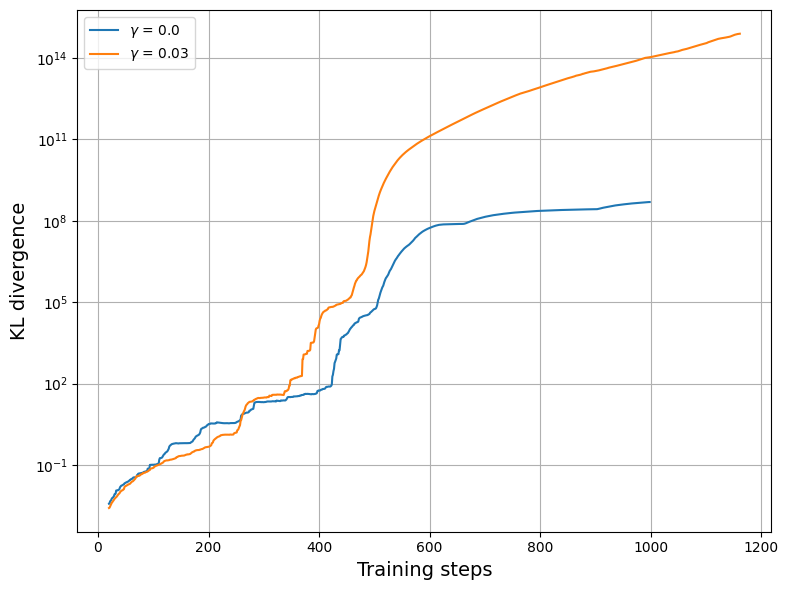

In [ ]:
plt.figure(figsize=(8, 6))
plot(df1["Loss/KL divergence"] / 81, start=20, alpha=0.01, label=r"$\gamma$ = 0.0")
plot(df2["Loss/KL divergence"] / 81, start=20, alpha=0.01, label=r"$\gamma$ = 0.03")
plt.xlabel("Training steps", fontsize=14)
plt.ylabel("KL divergence", fontsize=14)
# plt.title(col, fontsize=14)
# plt.legend(fontsize=14)
plt.grid(True)
plt.legend()
plt.yscale("log")
plt.tight_layout()

# plt.savefig(f"../Thesis/sections/figures/rl_training_progress/overfit/ESPO/kl_divergence.pdf")
plt.show()

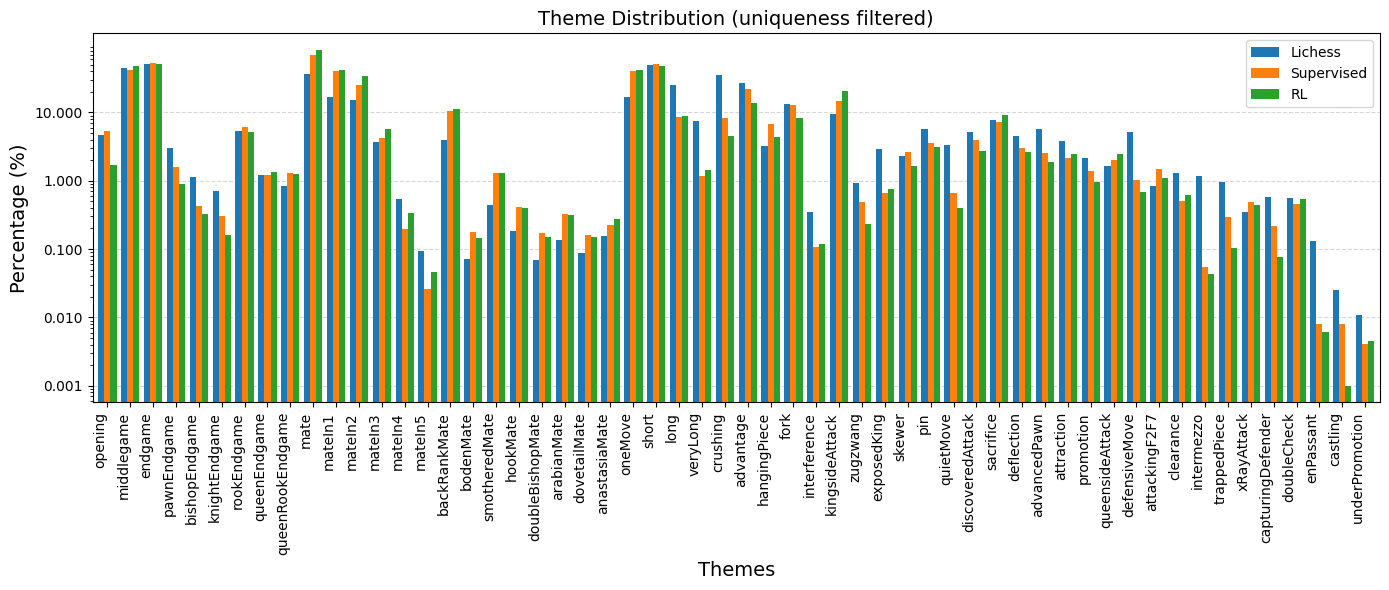

In [41]:
from rl.espo import state_of_game_tokens, endgames, is_mate, mate_lengths, types_of_mate, lengths, winnings, other


path = Path("./Generate_positions/final_model/supervised/v4/test_context_no_move_last.csv")
supervised = pd.read_csv(path)
supervised = supervised[supervised["is_puzzle"] & supervised["themes_match"]]
path = Path("./Generate_positions/final_model/rl/full_diversity11_3500/test_context_no_move_last.csv")
rl = pd.read_csv(path)
rl = rl[rl["is_puzzle"] & rl["themes_match"]]
path = Path("./Generate_positions/Lichess/lichess_first_time_move_found_division_50.csv")
lichess = pd.read_csv(path)
lichess = lichess[lichess["is_puzzle"]]

supervised["actual_themes"] = supervised["actual_themes"].apply(ast.literal_eval)
rl["actual_themes"] = rl["actual_themes"].apply(ast.literal_eval)
lichess["target_themes"] = lichess["target_themes"].apply(ast.literal_eval)

unique_elements = [*state_of_game_tokens, *endgames, is_mate, *mate_lengths, *types_of_mate, *lengths, *winnings, *other]

items = {}
for item in unique_elements:
    if item == "equality":
        continue
    filtered_supervised = supervised[supervised["actual_themes"].apply(lambda x: item in x)]
    filtered_rl = rl[rl["actual_themes"].apply(lambda x: item in x)]
    filtered_lichess = lichess[lichess["target_themes"].apply(lambda x: item in x)]
    
    # counter_intuitive = 100 * filtered_supervised["counter_intuitive"].mean()
    items[item] = 100 * len(filtered_lichess) / len(lichess), 100 * len(filtered_supervised) / len(supervised), 100 * len(filtered_rl) / len(rl)

df_plot = pd.DataFrame.from_dict(items, orient="index", columns=["Lichess", "Supervised", "RL"])
# df_plot = df_plot.sort_values(by=df_plot.index, ascending=False)
# df_plot = df_plot.sort_index(ascending=True)

# colors = ["#4C72B0", "#DD8452", "#55A868"]
# colors = ["#6B8EAD", "#E39B70", "#77AB7A"]
# df_plot.plot(kind="bar", figsize=(14, 6), width=0.8, color=colors)
df_plot.plot(kind="bar", figsize=(14, 6), width=0.8)
plt.title("Theme Distribution (uniqueness filtered)", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)
plt.xlabel("Themes", fontsize=14)
plt.xticks(rotation=90, ha="right")
plt.yscale("log")
plt.gca().set_axisbelow(True)
plt.grid(axis="y", zorder=0, linestyle='--', alpha=0.5)
plt.yticks([10.0, 1.00, 0.10, 0.01, 0.001])
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter())
plt.tight_layout()
# plt.savefig("../Thesis/sections/figures/other/theme_distribution.pdf")


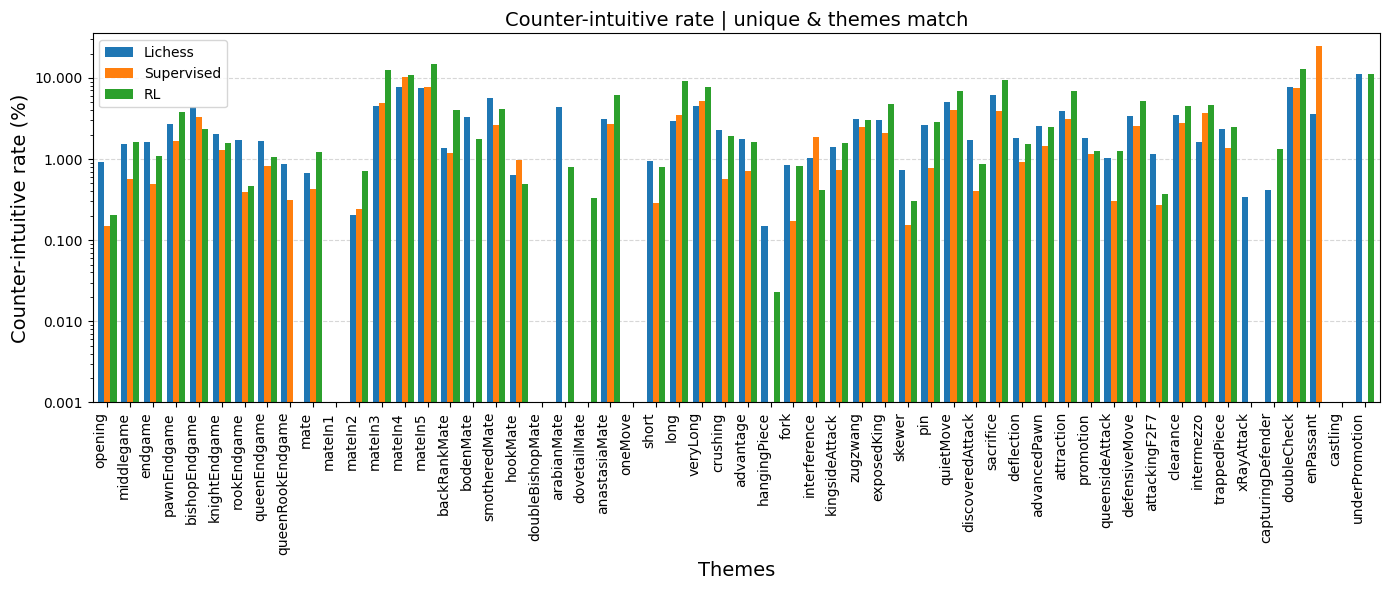

In [43]:
from rl.espo import state_of_game_tokens, endgames, is_mate, mate_lengths, types_of_mate, lengths, winnings, other


path = Path("./Generate_positions/final_model/supervised/v4/test_context_no_move_last.csv")
supervised = pd.read_csv(path)
supervised = supervised[supervised["is_puzzle"] & supervised["themes_match"]]
path = Path("./Generate_positions/final_model/rl/full_diversity11_3500/test_context_no_move_last.csv")
rl = pd.read_csv(path)
rl = rl[rl["is_puzzle"] & rl["themes_match"]]
path = Path("./Generate_positions/Lichess/lichess_first_time_move_found_division_50.csv")
lichess = pd.read_csv(path)
lichess = lichess[lichess["is_puzzle"]]

supervised["actual_themes"] = supervised["actual_themes"].apply(ast.literal_eval)
rl["actual_themes"] = rl["actual_themes"].apply(ast.literal_eval)
lichess["target_themes"] = lichess["target_themes"].apply(ast.literal_eval)

unique_elements = [*state_of_game_tokens, *endgames, is_mate, *mate_lengths, *types_of_mate, *lengths, *winnings, *other]

items = {}
for item in unique_elements:
    if item == "equality":
        continue
    filtered_supervised = supervised[supervised["actual_themes"].apply(lambda x: item in x)]
    filtered_rl = rl[rl["actual_themes"].apply(lambda x: item in x)]
    filtered_lichess = lichess[lichess["target_themes"].apply(lambda x: item in x)]
    
    # counter_intuitive = 100 * filtered_supervised["counter_intuitive"].mean()
    # items[item] = 100 * len(filtered_lichess) / len(lichess), 100 * len(filtered_supervised) / len(supervised), 100 * len(filtered_rl) / len(rl)
    items[item] = 100 * filtered_lichess["counter_intuitive"].mean(), 100 * filtered_supervised["counter_intuitive"].mean(), 100 * filtered_rl["counter_intuitive"].mean()

df_plot = pd.DataFrame.from_dict(items, orient="index", columns=["Lichess", "Supervised", "RL"])
# df_plot = df_plot.sort_values(by=df_plot.index, ascending=False)
# df_plot = df_plot.sort_index(ascending=True)

# colors = ["#4C72B0", "#DD8452", "#55A868"]
# colors = ["#6B8EAD", "#E39B70", "#77AB7A"]
# df_plot.plot(kind="bar", figsize=(14, 6), width=0.8, color=colors)
df_plot.plot(kind="bar", figsize=(14, 6), width=0.8)
plt.title("Counter-intuitive rate | unique & themes match", fontsize=14)
plt.ylabel("Counter-intuitive rate (%)", fontsize=14)
plt.xlabel("Themes", fontsize=14)
plt.xticks(rotation=90, ha="right")
plt.yscale("log")
plt.gca().set_axisbelow(True)
plt.grid(axis="y", zorder=0, linestyle='--', alpha=0.5)
plt.yticks([10.0, 1.00, 0.10, 0.01, 0.001])
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter())
plt.tight_layout()
# plt.savefig("../Thesis/sections/figures/other/ci_distribution_over_themes.pdf")
